<a href="https://colab.research.google.com/github/adenurchalisa/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install "transformers>=4.41.0" "accelerate>=0.33.0" "torch>=2.2.0" pandas>=2.2.0 seaborn>=0.13.0 matplotlib>=3.8.0 scikit-learn>=1.4.0 tqdm>=4.66.0

In [2]:
import os, sys, re, glob, json, textwrap, random
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
import torch
from transformers import pipeline

In [4]:
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

Torch: 2.8.0+cu126 | CUDA available: True


In [5]:
REPO_URL = "https://github.com/adenurchalisa/Sentiment-Analysis.git"
REPO_NAME = "Sentiment-Analysis"

In [6]:
DATASET_SEARCH_GLOB = [
    "DATA INCLUSIVE EDU*.csv",
    "*Inclusive*Edu*.csv",
    "*INCLUSIVE*EDU*.csv",
    "data/*.csv",
    "*.csv"
]

DATASET_PATH = ""

BASE_DIR = Path("/content")
REPO_DIR = BASE_DIR / REPO_NAME
OUTPUT_DIR = REPO_DIR / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPO_DIR, OUTPUT_DIR

(PosixPath('/content/Sentiment-Analysis'),
 PosixPath('/content/Sentiment-Analysis/data/processed'))

In [7]:
import subprocess, shutil

if REPO_DIR.exists():
    print(f"Repository already exists at: {REPO_DIR}")
else:
    print("Cloning repository...")
    !git clone $REPO_URL $REPO_DIR

print("Repo content:")
print("\n".join([str(p) for p in REPO_DIR.iterdir()]))

Repository already exists at: /content/Sentiment-Analysis
Repo content:
/content/Sentiment-Analysis/data


In [10]:
# Cell 3c: Force re-clone and verify the dataset exists
import shutil, subprocess, os
from pathlib import Path

REPO_URL = "https://github.com/adenurchalisa/Sentiment-Analysis.git"
REPO_NAME = "Sentiment-Analysis"
BASE_DIR = Path("/content")
REPO_DIR = BASE_DIR / REPO_NAME
OUTPUT_DIR = REPO_DIR / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Clean and clone
if REPO_DIR.exists():
    print("Removing existing repo for a clean clone...")
    shutil.rmtree(REPO_DIR)
print("Cloning fresh...")
!git clone --depth=1 $REPO_URL $REPO_DIR

print("\nGit branch and files:")
!git -C $REPO_DIR rev-parse --abbrev-ref HEAD
!ls -lah $REPO_DIR

# Verify the dataset path we know exists in the repo
DATASET_PATH = "DATA INCLUSIVE EDU.xlsx - Sheet1.csv"
dataset_abs = REPO_DIR / DATASET_PATH
print("\nExpected dataset path:", dataset_abs)
print("Exists?", dataset_abs.exists())

Removing existing repo for a clean clone...
Cloning fresh...
Cloning into '/content/Sentiment-Analysis'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.

Git branch and files:
main
total 16K
drwxr-xr-x 3 root root 4.0K Sep 27 08:41  .
drwxr-xr-x 1 root root 4.0K Sep 27 08:41  ..
-rw-r--r-- 1 root root 2.1K Sep 27 08:41 'DATA INCLUSIVE EDU.xlsx - Sheet1.csv'
drwxr-xr-x 8 root root 4.0K Sep 27 08:41  .git

Expected dataset path: /content/Sentiment-Analysis/DATA INCLUSIVE EDU.xlsx - Sheet1.csv
Exists? True


In [9]:
from pathlib import Path

cand_csv = sorted([p for p in REPO_DIR.rglob("*.csv")])
cand_xlsx = sorted([p for p in REPO_DIR.rglob("*.xlsx")])

print("CSV candidates:")
for p in cand_csv:
    print("-", p.relative_to(REPO_DIR))
print("\nXLSX candidates:")
for p in cand_xlsx:
    print("-", p.relative_to(REPO_DIR))

if not cand_csv and not cand_xlsx:
    print("\nNo CSV/XLSX files found. Periksa apakah repo sudah ter-clone dengan benar atau file ada di subfolder lain.")

CSV candidates:

XLSX candidates:

No CSV/XLSX files found. Periksa apakah repo sudah ter-clone dengan benar atau file ada di subfolder lain.


In [11]:
# Cell 4 (final fix): Resolve dataset path or download from GitHub raw as fallback
import urllib.parse, requests

RAW_URL = "https://raw.githubusercontent.com/adenurchalisa/Sentiment-Analysis/main/" + urllib.parse.quote(DATASET_PATH)

dataset_file = REPO_DIR / DATASET_PATH
if not dataset_file.exists():
    print(f"Dataset not found locally at {dataset_file}. Downloading from GitHub raw...")
    r = requests.get(RAW_URL)
    if r.status_code != 200:
        raise FileNotFoundError(f"Failed to download dataset from {RAW_URL}. HTTP {r.status_code}")
    dataset_file.parent.mkdir(parents=True, exist_ok=True)
    with open(dataset_file, "wb") as f:
        f.write(r.content)
    print("Downloaded to:", dataset_file)
else:
    print("Dataset found locally:", dataset_file)

# Quick peek
import pandas as pd
df_chk = pd.read_csv(dataset_file)
print("Shape:", df_chk.shape)
print(df_chk.head(3))

Dataset found locally: /content/Sentiment-Analysis/DATA INCLUSIVE EDU.xlsx - Sheet1.csv
Shape: (8, 3)
                                            Theme  \
0  Assessment Mechanisms and Differentiated Tasks   
1  Assessment Mechanisms and Differentiated Tasks   
2  Seating Arrangements and Classroom Environment   

                                               Quote Interviewee  
0  If the children can handle the regular tasks, ...         SDY  
1  Before being accepted here, students undergo a...         IRG  
2  Usually, inclusive students sit at the back. B...         SDY  


In [12]:
# Cell 5: Load dataset and basic sanitation
def load_dataset(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    # Normalize expected columns: Theme, Quote, Interviewee
    columns_lower = {c.lower(): c for c in df.columns}
    def get_col(*aliases):
        for a in aliases:
            if a.lower() in columns_lower:
                return columns_lower[a.lower()]
        return None

    theme_col = get_col("Theme", "Themes", "Category")
    quote_col = get_col("Quote", "Text", "Utterance", "Statement")
    who_col   = get_col("Interviewee", "Speaker", "Source")

    required = {"Theme": theme_col, "Quote": quote_col, "Interviewee": who_col}
    missing = [k for k,v in required.items() if v is None]
    if missing:
        raise ValueError(f"Missing required columns in CSV: {missing}. Found columns: {list(df.columns)}")

    # Keep only relevant columns + optional ManualSentiment if present
    keep_cols = [theme_col, quote_col, who_col] + ([columns_lower["manualsentiment"]] if "manualsentiment" in columns_lower else [])
    df = df[keep_cols].copy()
    df.columns = ["Theme", "Quote", "Interviewee"] + (["ManualSentiment"] if len(keep_cols)==4 else [])

    # Basic cleaning
    def clean_text(s):
        if pd.isna(s): return ""
        s = str(s).strip()
        s = re.sub(r"\s+", " ", s)
        s = s.replace("“","\"").replace("”","\"").replace("’","'")
        return s
    df["Quote"] = df["Quote"].apply(clean_text)
    df["Theme"] = df["Theme"].astype(str).str.strip()
    df["Interviewee"] = df["Interviewee"].astype(str).str.strip()

    # Drop empty quotes if any
    df = df[df["Quote"].str.len() > 0].reset_index(drop=True)
    return df

df = load_dataset(dataset_file)
print(df.head(3))
print(f"Rows: {len(df)}, Columns: {list(df.columns)}")

                                            Theme  \
0  Assessment Mechanisms and Differentiated Tasks   
1  Assessment Mechanisms and Differentiated Tasks   
2  Seating Arrangements and Classroom Environment   

                                               Quote Interviewee  
0  If the children can handle the regular tasks, ...         SDY  
1  Before being accepted here, students undergo a...         IRG  
2  Usually, inclusive students sit at the back. B...         SDY  
Rows: 8, Columns: ['Theme', 'Quote', 'Interviewee']


In [14]:
from pathlib import Path

# Tentukan folder output
OUTPUT_DIR = Path("/content/Sentiment-Analysis/data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Simpan hasil prediksi (lanjutan dari Cell 6)
pred_path = OUTPUT_DIR / "pred_sentiment.csv"
df.to_csv(pred_path, index=False)
print("Saved predictions to:", pred_path)

Saved predictions to: /content/Sentiment-Analysis/data/processed/pred_sentiment.csv


In [15]:
# Cell 6: Sentiment inference using Hugging Face pipeline (English)
DEVICE = 0 if torch.cuda.is_available() else -1
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

LABEL_MAP = {
    "positive": "positive",
    "negative": "negative",
    "neutral": "neutral",
    # Uppercase variants
    "POSITIVE": "positive",
    "NEGATIVE": "negative",
    "NEUTRAL": "neutral",
    # Index labels used by some checkpoints
    "LABEL_0": "negative",
    "LABEL_1": "neutral",
    "LABEL_2": "positive",
}

def normalize_label(label: str) -> str:
    return LABEL_MAP.get(label, LABEL_MAP.get(str(label).upper(), "neutral"))

clf = pipeline(
    task="sentiment-analysis",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=DEVICE
)

texts = df["Quote"].tolist()
preds = []
BATCH = 32
for i in tqdm(range(0, len(texts), BATCH), desc="Predicting"):
    batch = texts[i:i+BATCH]
    out = clf(batch, truncation=True, max_length=256)
    preds.extend(out)

df["pred_label_raw"] = [o["label"] for o in preds]
df["pred_score"]     = [float(o.get("score", 0.0)) for o in preds]
df["pred_label"]     = df["pred_label_raw"].apply(normalize_label)
df["model_name"]     = MODEL_NAME

pred_path = OUTPUT_DIR / "pred_sentiment.csv"
df.to_csv(pred_path, index=False)
print(f"Saved predictions to: {pred_path}")
df.head(5)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Predicting: 100%|██████████| 1/1 [00:00<00:00, 11.89it/s]

Saved predictions to: /content/Sentiment-Analysis/data/processed/pred_sentiment.csv


,Theme,Quote,Interviewee,pred_label_raw,pred_score,pred_label,model_name
0,Assessment Mechanisms and Differentiated Tasks,"If the children can handle the regular tasks, ...",SDY,neutral,0.641195,neutral,cardiffnlp/twitter-roberta-base-sentiment-latest
1,Assessment Mechanisms and Differentiated Tasks,"Before being accepted here, students undergo a...",IRG,neutral,0.907486,neutral,cardiffnlp/twitter-roberta-base-sentiment-latest
2,Seating Arrangements and Classroom Environment,"Usually, inclusive students sit at the back. B...",SDY,neutral,0.721553,neutral,cardiffnlp/twitter-roberta-base-sentiment-latest
3,Limit on the Number of Students with Disabilities,"Usually, a maximum of five students with disab...",IRG,neutral,0.825921,neutral,cardiffnlp/twitter-roberta-base-sentiment-latest
4,Limit on the Number of Students with Disabilities,"For example, in one grade, there are usually o...",SDY,neutral,0.617250,neutral,cardiffnlp/twitter-roberta-base-sentiment-latest


In [16]:
# Cell 7: Aggregation (overall and per theme)
def aggregate_sentiment(df: pd.DataFrame, prefer_manual=True):
    label_col = "pred_label"
    if prefer_manual and "ManualSentiment" in df.columns:
        label_col = "ManualSentiment"

    # Overall distribution
    overall = (
        df[label_col].value_counts(dropna=False)
          .rename_axis("label").reset_index(name="count")
          .sort_values("label")
    )
    overall["proportion"] = overall["count"] / overall["count"].sum()

    # Per-theme distribution
    per_theme = (
        df.groupby(["Theme", label_col])
          .size().rename("count")
          .reset_index()
          .sort_values(["Theme", label_col])
    )
    per_theme["proportion_within_theme"] = per_theme.groupby("Theme")["count"].transform(lambda x: x / x.sum())
    return label_col, overall, per_theme

# Jika kamu tidak restart runtime, df sudah ada dari Cell 6 dan langsung jalan.
# Jika kamu sempat re-clone atau restart runtime, load dulu:
# from pathlib import Path
# OUTPUT_DIR = Path("/content/Sentiment-Analysis/data/processed")
# df = pd.read_csv(OUTPUT_DIR / "pred_sentiment.csv")

label_col, overall, per_theme = aggregate_sentiment(df, prefer_manual=True)

from pathlib import Path
OUTPUT_DIR = Path("/content/Sentiment-Analysis/data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

overall_path = OUTPUT_DIR / "agg_overall.csv"
per_theme_path = OUTPUT_DIR / "agg_per_theme.csv"
overall_path.parent.mkdir(parents=True, exist_ok=True)
per_theme_path.parent.mkdir(parents=True, exist_ok=True)

overall.to_csv(overall_path, index=False)
per_theme.to_csv(per_theme_path, index=False)

print("Label source column used:", label_col)
print("Overall distribution:")
display(overall)
print("Per-theme distribution (first 20 rows):")
display(per_theme.head(20))
print(f"Saved to:\n- {overall_path}\n- {per_theme_path}")

Label source column used: pred_label
Overall distribution:


,label,count,proportion
0,neutral,8,1.0


Per-theme distribution (first 20 rows):


,Theme,pred_label,count,proportion_within_theme
0,Assessment Mechanisms and Differentiated Tasks,neutral,2,1.0
1,Limit on the Number of Students with Disabilities,neutral,2,1.0
2,Monitoring Academic and Social Development,neutral,1,1.0
3,Seating Arrangements and Classroom Environment,neutral,1,1.0
4,Support Strategies and Motivation,neutral,2,1.0


Saved to:
- /content/Sentiment-Analysis/data/processed/agg_overall.csv
- /content/Sentiment-Analysis/data/processed/agg_per_theme.csv


In [17]:
# Cell 8: Diagnostics for baseline predictions
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path("/content/Sentiment-Analysis/data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Fallback: load if df not in memory
if "df" not in locals():
    df = pd.read_csv(OUTPUT_DIR / "pred_sentiment.csv")

print("Baseline label counts:")
print(df["pred_label"].value_counts())
print("\nBaseline score summary:")
print(df["pred_score"].describe())

# Show low-confidence neutrals (if any)
low_conf_neutral = df[(df["pred_label"] == "neutral") & (df["pred_score"] < 0.60)]
print(f"\nLow-confidence neutral count: {len(low_conf_neutral)}")
display(low_conf_neutral[["Theme","Interviewee","Quote","pred_score"]])

Baseline label counts:
pred_label
neutral    8
Name: count, dtype: int64

Baseline score summary:
count    8.000000
mean     0.748590
std      0.107025
min      0.617250
25%      0.644395
50%      0.768130
75%      0.817844
max      0.907486
Name: pred_score, dtype: float64

Low-confidence neutral count: 0


,Theme,Interviewee,Quote,pred_score


In [18]:
# Cell 9: Alternative model (Siebert) with neutral via threshold
from transformers import pipeline
import torch

DEVICE = 0 if torch.cuda.is_available() else -1
ALT_MODEL = "siebert/sentiment-roberta-large-english"  # binary: positive/negative
NEUTRAL_THRESHOLD = 0.55  # tune 0.5–0.65 if needed
BATCH = 16

alt_clf = pipeline("sentiment-analysis", model=ALT_MODEL, tokenizer=ALT_MODEL, device=DEVICE)

texts = df["Quote"].astype(str).tolist()
out_alt = []
for i in range(0, len(texts), BATCH):
    out_alt.extend(alt_clf(texts[i:i+BATCH], truncation=True, max_length=256))

# Convert to 3-class with neutral threshold
def add_neutral_from_binary(outputs, neutral_threshold=0.55):
    labels, scores = [], []
    for o in outputs:
        lab = o["label"].lower()  # 'positive' / 'negative'
        sc = float(o["score"])
        if sc < neutral_threshold:
            labels.append("neutral")
        else:
            labels.append(lab)
        scores.append(sc)
    return labels, scores

alt_labels, alt_scores = add_neutral_from_binary(out_alt, neutral_threshold=NEUTRAL_THRESHOLD)

df["pred_label_alt_raw"] = [o["label"].lower() for o in out_alt]
df["pred_score_alt_raw"] = [float(o["score"]) for o in out_alt]
df["pred_label_alt"] = alt_labels
df["pred_score_alt"] = alt_scores
df["model_name_alt"] = ALT_MODEL

print("Alternative label counts:")
print(df["pred_label_alt"].value_counts())

pred_path_alt = OUTPUT_DIR / "pred_sentiment_alt.csv"
pred_path_alt.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(pred_path_alt, index=False)
print("Saved alternative predictions to:", pred_path_alt)
display(df[["Theme","Quote","pred_label","pred_score","pred_label_alt","pred_score_alt"]])

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


Alternative label counts:
pred_label_alt
positive    5
negative    3
Name: count, dtype: int64
Saved alternative predictions to: /content/Sentiment-Analysis/data/processed/pred_sentiment_alt.csv


,Theme,Quote,pred_label,pred_score,pred_label_alt,pred_score_alt
0,Assessment Mechanisms and Differentiated Tasks,"If the children can handle the regular tasks, ...",neutral,0.641195,negative,0.986539
1,Assessment Mechanisms and Differentiated Tasks,"Before being accepted here, students undergo a...",neutral,0.907486,positive,0.998185
2,Seating Arrangements and Classroom Environment,"Usually, inclusive students sit at the back. B...",neutral,0.721553,positive,0.996649
3,Limit on the Number of Students with Disabilities,"Usually, a maximum of five students with disab...",neutral,0.825921,negative,0.979018
4,Limit on the Number of Students with Disabilities,"For example, in one grade, there are usually o...",neutral,0.617250,negative,0.995160
5,Support Strategies and Motivation,"If a student feels shy or unwilling, I usually...",neutral,0.645461,positive,0.998637
6,Support Strategies and Motivation,There are students who initially find it diffi...,neutral,0.815151,positive,0.998818
7,Monitoring Academic and Social Development,There are routine assessments by psychologists...,neutral,0.814707,positive,0.998651


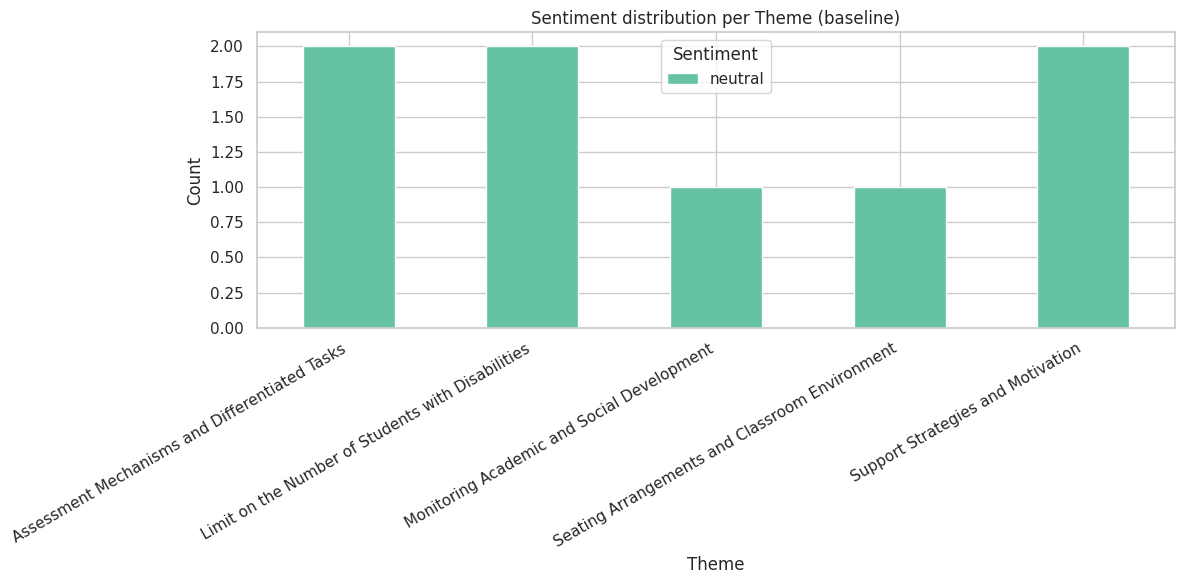

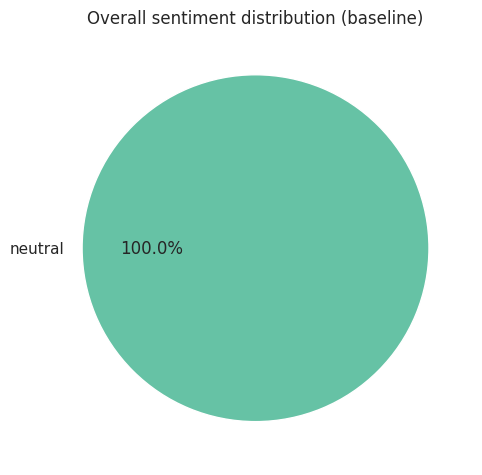

Saved to:
- /content/Sentiment-Analysis/data/processed/agg_overall_baseline.csv
- /content/Sentiment-Analysis/data/processed/agg_per_theme_baseline.csv
- /content/Sentiment-Analysis/data/processed/sentiment_per_theme_stacked_baseline.png
- /content/Sentiment-Analysis/data/processed/sentiment_overall_pie_baseline.png


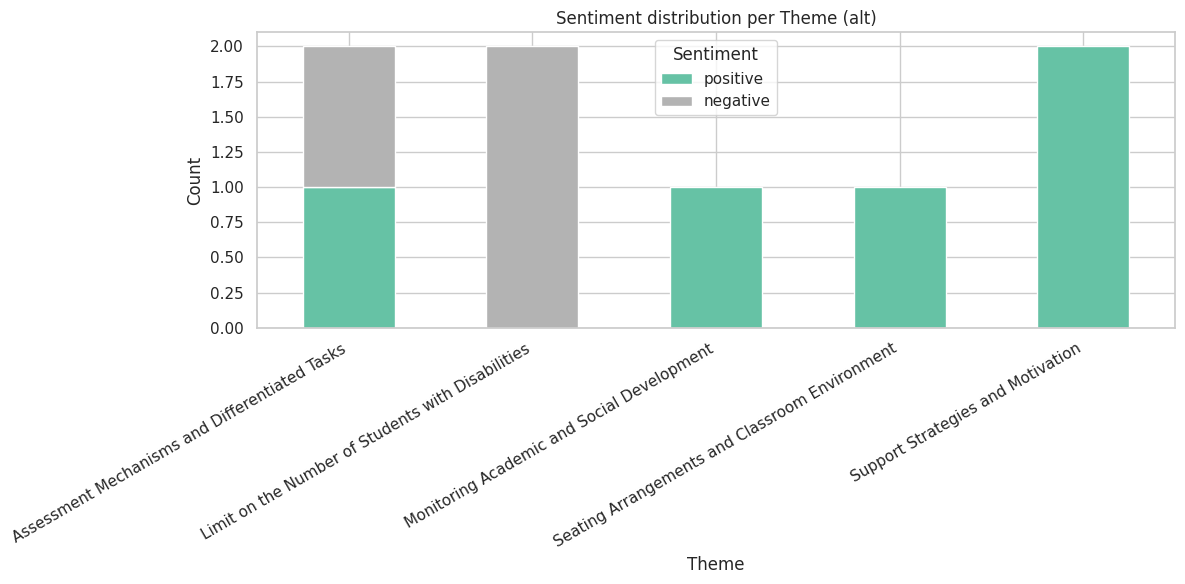

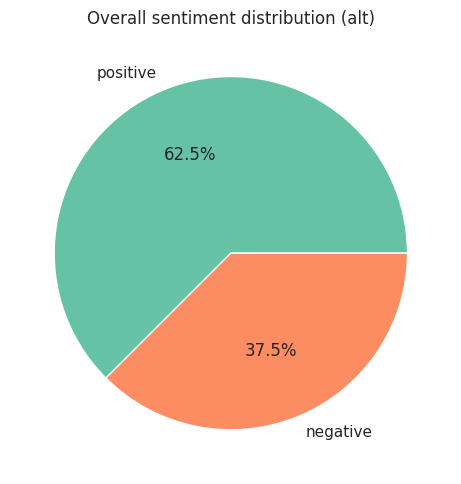

Saved to:
- /content/Sentiment-Analysis/data/processed/agg_overall_alt.csv
- /content/Sentiment-Analysis/data/processed/agg_per_theme_alt.csv
- /content/Sentiment-Analysis/data/processed/sentiment_per_theme_stacked_alt.png
- /content/Sentiment-Analysis/data/processed/sentiment_overall_pie_alt.png


In [19]:
# Cell 10: Aggregation and plots helper, then run for baseline and alt
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

def aggregate_and_plot(df, label_col, out_prefix):
    # Aggregate
    overall = (
        df[label_col].value_counts(dropna=False)
          .rename_axis("label").reset_index(name="count")
    )
    overall["proportion"] = overall["count"] / overall["count"].sum()

    per_theme = (
        df.groupby(["Theme", label_col])
          .size().rename("count")
          .reset_index()
    )
    per_theme["proportion_within_theme"] = per_theme.groupby("Theme")["count"].transform(lambda x: x / x.sum())

    # Save CSVs
    overall_path = OUTPUT_DIR / f"agg_overall_{out_prefix}.csv"
    per_theme_path = OUTPUT_DIR / f"agg_per_theme_{out_prefix}.csv"
    overall_path.parent.mkdir(parents=True, exist_ok=True)
    overall.to_csv(overall_path, index=False)
    per_theme.to_csv(per_theme_path, index=False)

    # Plot stacked bar per theme
    pivot = per_theme.pivot(index="Theme", columns=label_col, values="count").fillna(0).astype(int)
    # Ensure consistent order
    cols = [c for c in ["positive","neutral","negative"] if c in pivot.columns] + [c for c in pivot.columns if c not in ["positive","neutral","negative"]]
    pivot = pivot[cols]

    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="Set2")
    plt.title(f"Sentiment distribution per Theme ({out_prefix})")
    plt.xlabel("Theme")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Sentiment")
    plt.tight_layout()
    plot_path = OUTPUT_DIR / f"sentiment_per_theme_stacked_{out_prefix}.png"
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_path, dpi=150)
    plt.show()

    # Pie chart
    fig, ax2 = plt.subplots(figsize=(5,5))
    ax2.pie(overall["count"], labels=overall["label"], autopct="%1.1f%%", colors=sns.color_palette("Set2", n_colors=len(overall)))
    ax2.set_title(f"Overall sentiment distribution ({out_prefix})")
    plt.tight_layout()
    pie_path = OUTPUT_DIR / f"sentiment_overall_pie_{out_prefix}.png"
    plt.savefig(pie_path, dpi=150)
    plt.show()

    print("Saved to:")
    print("-", overall_path)
    print("-", per_theme_path)
    print("-", plot_path)
    print("-", pie_path)
    return overall, per_theme

# Run for baseline
overall_base, per_theme_base = aggregate_and_plot(df, label_col="pred_label", out_prefix="baseline")

# Run for alternative
overall_alt, per_theme_alt = aggregate_and_plot(df, label_col="pred_label_alt", out_prefix="alt")

In [20]:
# Cell 11: Zero-shot classification (BART MNLI) to 3 labels
from transformers import pipeline
import torch

DEVICE = 0 if torch.cuda.is_available() else -1
ZS_MODEL = "facebook/bart-large-mnli"
candidate_labels = ["positive", "neutral", "negative"]

zs = pipeline("zero-shot-classification", model=ZS_MODEL, device=DEVICE)

zs_out = zs(df["Quote"].astype(str).tolist(), candidate_labels=candidate_labels, multi_label=False)
# Top-1 label and score
zs_labels = [o["labels"][0] for o in zs_out]
zs_scores = [float(o["scores"][0]) for o in zs_out]

df["pred_label_zs"] = zs_labels
df["pred_score_zs"] = zs_scores
df["model_name_zs"] = ZS_MODEL

print("Zero-shot label counts:")
print(df["pred_label_zs"].value_counts())

pred_path_zs = OUTPUT_DIR / "pred_sentiment_zero_shot.csv"
pred_path_zs.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(pred_path_zs, index=False)
print("Saved zero-shot predictions to:", pred_path_zs)
display(df[["Theme","Quote","pred_label_zs","pred_score_zs"]])

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Zero-shot label counts:
pred_label_zs
positive    4
neutral     3
negative    1
Name: count, dtype: int64
Saved zero-shot predictions to: /content/Sentiment-Analysis/data/processed/pred_sentiment_zero_shot.csv


,Theme,Quote,pred_label_zs,pred_score_zs
0,Assessment Mechanisms and Differentiated Tasks,"If the children can handle the regular tasks, ...",positive,0.497292
1,Assessment Mechanisms and Differentiated Tasks,"Before being accepted here, students undergo a...",neutral,0.355253
2,Seating Arrangements and Classroom Environment,"Usually, inclusive students sit at the back. B...",neutral,0.461972
3,Limit on the Number of Students with Disabilities,"Usually, a maximum of five students with disab...",negative,0.738121
4,Limit on the Number of Students with Disabilities,"For example, in one grade, there are usually o...",positive,0.690497
5,Support Strategies and Motivation,"If a student feels shy or unwilling, I usually...",positive,0.672260
6,Support Strategies and Motivation,There are students who initially find it diffi...,positive,0.635417
7,Monitoring Academic and Social Development,There are routine assessments by psychologists...,neutral,0.427995


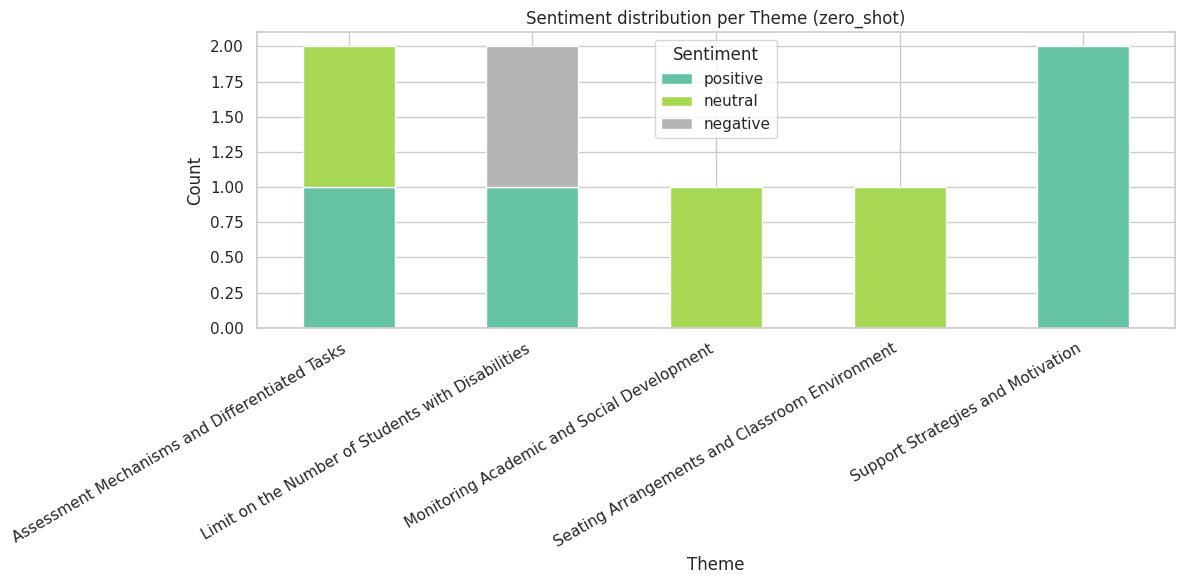

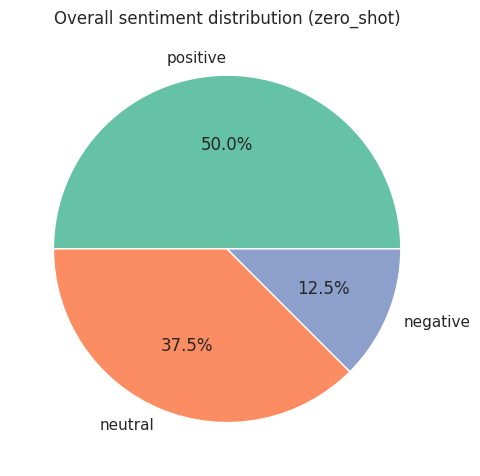

Saved to:
- /content/Sentiment-Analysis/data/processed/agg_overall_zero_shot.csv
- /content/Sentiment-Analysis/data/processed/agg_per_theme_zero_shot.csv
- /content/Sentiment-Analysis/data/processed/sentiment_per_theme_stacked_zero_shot.png
- /content/Sentiment-Analysis/data/processed/sentiment_overall_pie_zero_shot.png


In [21]:
# Cell 12: Aggregate and plot zero-shot results
overall_zs, per_theme_zs = aggregate_and_plot(df, label_col="pred_label_zs", out_prefix="zero_shot")

In [22]:
# Cell 13: Representative quotes per Theme and Sentiment (top-1 each)
import pandas as pd

def representative_quotes(df: pd.DataFrame, label_col: str, score_col: str, topk=1):
    tmp = df.copy()
    # If score_col not present (e.g., manual), use 1.0
    if score_col not in tmp.columns:
        tmp["__conf"] = 1.0
    else:
        tmp["__conf"] = tmp[score_col].fillna(0.0).astype(float)
    rows = []
    for (theme, lab), g in tmp.groupby(["Theme", label_col]):
        g_sorted = g.sort_values("__conf", ascending=False).head(topk)
        for _, r in g_sorted.iterrows():
            rows.append({
                "Theme": theme,
                "Sentiment": lab,
                "Interviewee": r["Interviewee"],
                "Confidence": float(r["__conf"]),
                "Quote": r["Quote"]
            })
    rep = pd.DataFrame(rows).sort_values(["Theme", "Sentiment"])
    return rep

rep_base = representative_quotes(df, "pred_label", "pred_score", topk=1)
rep_alt  = representative_quotes(df, "pred_label_alt", "pred_score_alt", topk=1)
rep_zs   = representative_quotes(df, "pred_label_zs", "pred_score_zs", topk=1)

rep_base_path = OUTPUT_DIR / "representative_quotes_baseline.csv"
rep_alt_path  = OUTPUT_DIR / "representative_quotes_alt.csv"
rep_zs_path   = OUTPUT_DIR / "representative_quotes_zero_shot.csv"
for pth, rep in [(rep_base_path, rep_base),(rep_alt_path, rep_alt),(rep_zs_path, rep_zs)]:
    pth.parent.mkdir(parents=True, exist_ok=True)
    rep.to_csv(pth, index=False)
    print("Saved:", pth)

display(rep_alt.head(10))

Saved: /content/Sentiment-Analysis/data/processed/representative_quotes_baseline.csv
Saved: /content/Sentiment-Analysis/data/processed/representative_quotes_alt.csv
Saved: /content/Sentiment-Analysis/data/processed/representative_quotes_zero_shot.csv


,Theme,Sentiment,Interviewee,Confidence,Quote
0,Assessment Mechanisms and Differentiated Tasks,negative,SDY,0.986539,"If the children can handle the regular tasks, ..."
1,Assessment Mechanisms and Differentiated Tasks,positive,IRG,0.998185,"Before being accepted here, students undergo a..."
2,Limit on the Number of Students with Disabilities,negative,SDY,0.995160,"For example, in one grade, there are usually o..."
3,Monitoring Academic and Social Development,positive,IRG,0.998651,There are routine assessments by psychologists...
4,Seating Arrangements and Classroom Environment,positive,SDY,0.996649,"Usually, inclusive students sit at the back. B..."
5,Support Strategies and Motivation,positive,IRG,0.998818,There are students who initially find it diffi...


In [23]:
# Cell 14: Text summary for reporting (baseline, alt, zero-shot)
def summarize(overall: pd.DataFrame, per_theme: pd.DataFrame, label_col: str, title: str, max_themes=50):
    lines = []
    total = overall["count"].sum()
    o_sorted = overall.sort_values("count", ascending=False)
    lines.append(f"{title} — Overall (n={total}): " + ", ".join([f"{r['label']}={r['count']} ({r['proportion']*100:.1f}%)" for _, r in o_sorted.iterrows()]))
    theme_counts = per_theme.groupby("Theme")["count"].sum().reset_index().sort_values("count", ascending=False)
    top_themes = theme_counts["Theme"].head(max_themes).tolist()
    lines.append("\nPer Theme:")
    for th in top_themes:
        subset = per_theme[per_theme["Theme"] == th].sort_values("count", ascending=False)
        total_th = subset["count"].sum()
        parts = [f"{r[label_col]}={r['count']} ({(r['count']/total_th)*100:.1f}%)" for _, r in subset.iterrows()]
        lines.append(f"- {th} (n={total_th}): " + ", ".join(parts))
    return "\n".join(lines)

summary_baseline = summarize(overall_base, per_theme_base, "pred_label", "Baseline (Twitter-RoBERTa)")
summary_alt      = summarize(overall_alt, per_theme_alt, "pred_label_alt", "Alternative (Siebert + neutral threshold)")
summary_zs       = summarize(overall_zs, per_theme_zs, "pred_label_zs", "Zero-shot (BART MNLI)")

summary_all = "\n\n".join([summary_baseline, summary_alt, summary_zs])

summary_path = OUTPUT_DIR / "summary_all_methods.txt"
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, "w") as f:
    f.write(summary_all)

print(summary_all)
print("\nSaved summary to:", summary_path)

Baseline (Twitter-RoBERTa) — Overall (n=8): neutral=8 (100.0%)

Per Theme:
- Assessment Mechanisms and Differentiated Tasks (n=2): neutral=2 (100.0%)
- Limit on the Number of Students with Disabilities (n=2): neutral=2 (100.0%)
- Support Strategies and Motivation (n=2): neutral=2 (100.0%)
- Monitoring Academic and Social Development (n=1): neutral=1 (100.0%)
- Seating Arrangements and Classroom Environment (n=1): neutral=1 (100.0%)

Alternative (Siebert + neutral threshold) — Overall (n=8): positive=5 (62.5%), negative=3 (37.5%)

Per Theme:
- Assessment Mechanisms and Differentiated Tasks (n=2): negative=1 (50.0%), positive=1 (50.0%)
- Limit on the Number of Students with Disabilities (n=2): negative=2 (100.0%)
- Support Strategies and Motivation (n=2): positive=2 (100.0%)
- Monitoring Academic and Social Development (n=1): positive=1 (100.0%)
- Seating Arrangements and Classroom Environment (n=1): positive=1 (100.0%)

Zero-shot (BART MNLI) — Overall (n=8): positive=4 (50.0%), neutral=

In [24]:
# Cell 15 (optional): Evaluation vs ManualSentiment if available
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if "ManualSentiment" in df.columns:
    for name, col in [("baseline","pred_label"),("alt","pred_label_alt"),("zero_shot","pred_label_zs")]:
        y_true = df["ManualSentiment"].astype(str)
        y_pred = df[col].astype(str)
        labels = sorted(set(y_true) | set(y_pred))
        print(f"\n=== Evaluation vs ManualSentiment ({name}) ===")
        print(classification_report(y_true, y_pred, labels=labels, digits=3))
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(5,5))
        disp.plot(ax=ax, cmap="Blues", values_format="d")
        plt.title(f"Confusion Matrix ({name})")
        plt.tight_layout()
        cm_path = OUTPUT_DIR / f"confusion_matrix_{name}.png"
        cm_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(cm_path, dpi=150)
        plt.show()
        print("Saved:", cm_path)
else:
    print("No ManualSentiment column. Skipping evaluation vs manual.")

No ManualSentiment column. Skipping evaluation vs manual.


In [25]:
# Cell 16 (optional): Side-by-side comparison table for all methods
cols = ["Theme","Interviewee","Quote",
        "pred_label","pred_score",
        "pred_label_alt","pred_score_alt",
        "pred_label_zs","pred_score_zs"]
compare = df[cols].copy()
compare_path = OUTPUT_DIR / "comparison_all_methods.csv"
compare_path.parent.mkdir(parents=True, exist_ok=True)
compare.to_csv(compare_path, index=False)
print("Saved comparison table to:", compare_path)
display(compare)

Saved comparison table to: /content/Sentiment-Analysis/data/processed/comparison_all_methods.csv


,Theme,Interviewee,Quote,pred_label,pred_score,pred_label_alt,pred_score_alt,pred_label_zs,pred_score_zs
0,Assessment Mechanisms and Differentiated Tasks,SDY,"If the children can handle the regular tasks, ...",neutral,0.641195,negative,0.986539,positive,0.497292
1,Assessment Mechanisms and Differentiated Tasks,IRG,"Before being accepted here, students undergo a...",neutral,0.907486,positive,0.998185,neutral,0.355253
2,Seating Arrangements and Classroom Environment,SDY,"Usually, inclusive students sit at the back. B...",neutral,0.721553,positive,0.996649,neutral,0.461972
3,Limit on the Number of Students with Disabilities,IRG,"Usually, a maximum of five students with disab...",neutral,0.825921,negative,0.979018,negative,0.738121
4,Limit on the Number of Students with Disabilities,SDY,"For example, in one grade, there are usually o...",neutral,0.617250,negative,0.995160,positive,0.690497
5,Support Strategies and Motivation,SDY,"If a student feels shy or unwilling, I usually...",neutral,0.645461,positive,0.998637,positive,0.672260
6,Support Strategies and Motivation,IRG,There are students who initially find it diffi...,neutral,0.815151,positive,0.998818,positive,0.635417
7,Monitoring Academic and Social Development,IRG,There are routine assessments by psychologists...,neutral,0.814707,positive,0.998651,neutral,0.427995
